
# 02_04 — Create a linear regression model

This notebook uses the California Housing dataset available from scikit-learn.


## Imports

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression


## Load the California Housing dataset

In [15]:

# Load the dataset as a pandas DataFrame
california = fetch_california_housing(as_frame=True)
X = california.data
y = california.target

X.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [23]:
X.drop('AveRooms', axis = 1)

KeyError: "['AveRooms'] not found in axis"

In [12]:
falses = california.data.isnull().sum()>0

## Fit a Linear Regression model

In [17]:

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## View coefficients and intercept

In [18]:
X.corr()

,MedInc,HouseAge,AveBedrms,Population,AveOccup,Latitude,Longitude
MedInc,1.000000,-0.119034,-0.062040,0.004834,0.018766,-0.079809,-0.015176
HouseAge,-0.119034,1.000000,-0.077747,-0.296244,0.013191,0.011173,-0.108197
AveBedrms,-0.062040,-0.077747,1.000000,-0.066197,-0.006181,0.069721,0.013344
Population,0.004834,-0.296244,-0.066197,1.000000,0.069863,-0.108785,0.099773
AveOccup,0.018766,0.013191,-0.006181,0.069863,1.000000,0.002366,0.002476
Latitude,-0.079809,0.011173,0.069721,-0.108785,0.002366,1.000000,-0.924664
Longitude,-0.015176,-0.108197,0.013344,0.099773,0.002476,-0.924664,1.000000


In [19]:

coefficients = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_

print('Intercept:', intercept)
print('Coefficients:')
print(coefficients)


Intercept: -39.680376976548416
Coefficients:
MedInc        3.796481e-01
HouseAge      9.797862e-03
AveBedrms     1.723076e-01
Population   -6.726050e-07
AveOccup     -3.593434e-03
Latitude     -4.626939e-01
Longitude    -4.709262e-01
dtype: float64


## Evaluate the Model

In [20]:
# output the r-squared of the model fit - % of variation explained by the model

model.score(X, y)

0.59988598004816

## Generate predictions

In [21]:

predictions = model.predict(X)

In [22]:
results_df = pd.DataFrame({'Actual': y, 'Predicted': predictions})
print(results_df.head())


   Actual  Predicted
0   4.526   4.083459
1   3.585   3.874266
2   3.521   3.811987
3   3.413   3.204635
4   3.422   2.525140


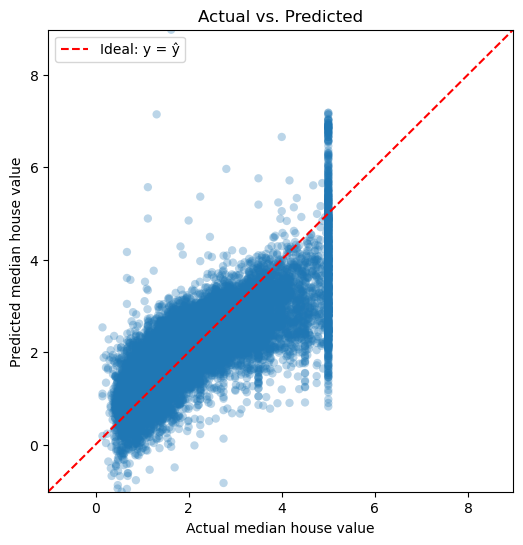

In [9]:
import matplotlib.pyplot as plt
import numpy as np

y_true = y
y_pred = predictions  # from model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.3, edgecolor="none")
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal: y = ŷ')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual median house value")
plt.ylabel("Predicted median house value")
plt.title("Actual vs. Predicted")
plt.legend()
plt.show()

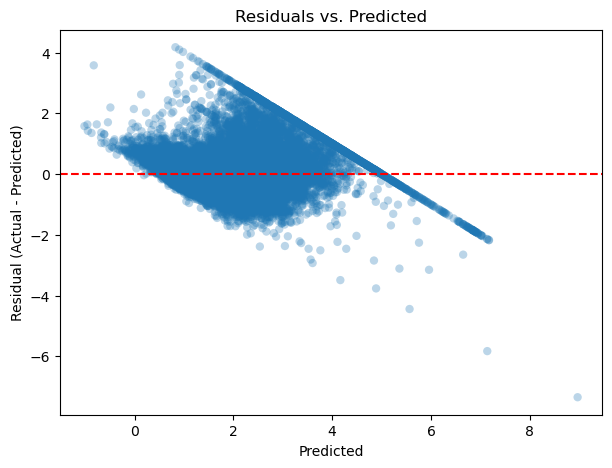

In [10]:
residuals = y_true - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.3, edgecolor="none")
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs. Predicted")
plt.show()

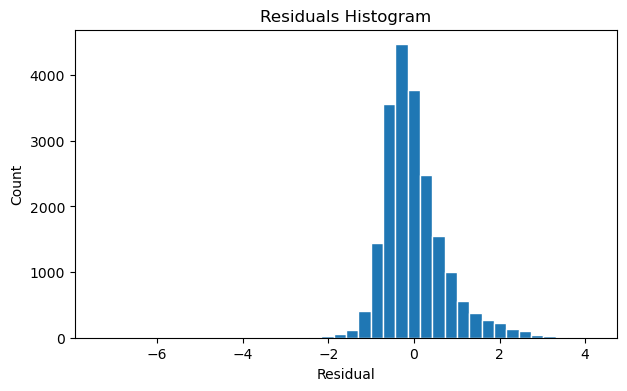

In [11]:
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=40, edgecolor="white")
plt.title("Residuals Histogram")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

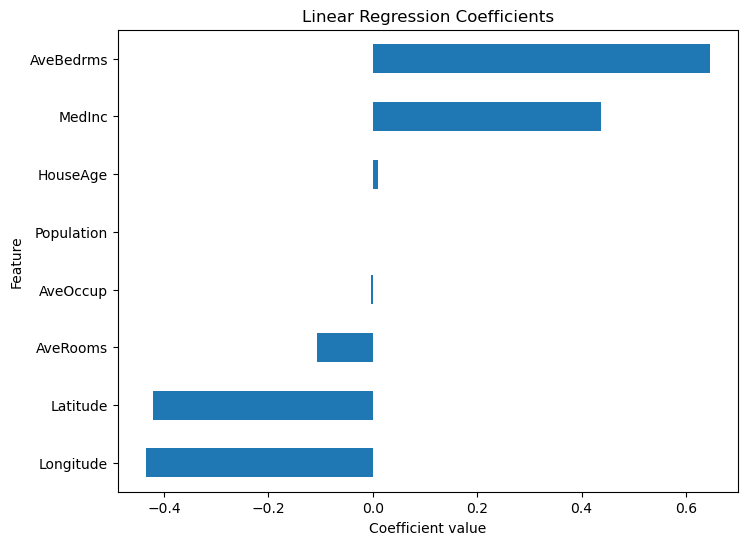

In [12]:
import pandas as pd
coef = pd.Series(model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8,6))
coef.plot(kind="barh")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

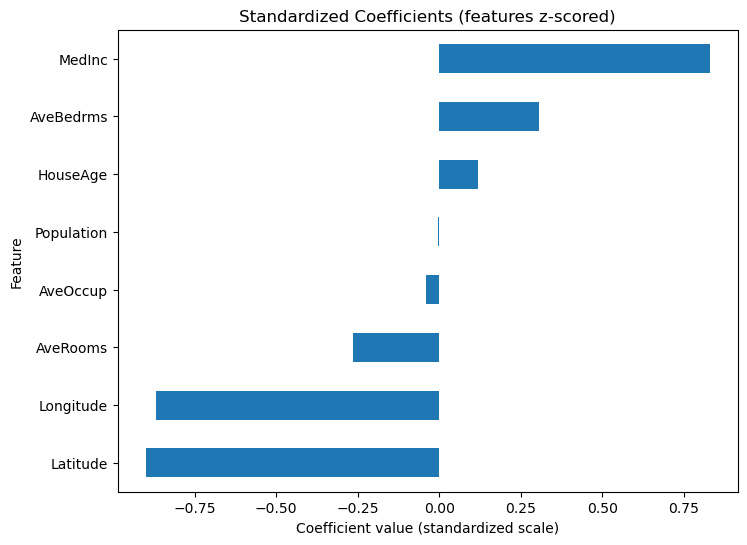

In [13]:
# Standardize features to compare coefficients fairly
X_std = (X - X.mean()) / X.std(ddof=0)
model_std = LinearRegression().fit(X_std, y)
coef_std = pd.Series(model_std.coef_, index=X.columns).sort_values()

plt.figure(figsize=(8,6))
coef_std.plot(kind="barh")
plt.title("Standardized Coefficients (features z-scored)")
plt.xlabel("Coefficient value (standardized scale)")
plt.ylabel("Feature")
plt.show()

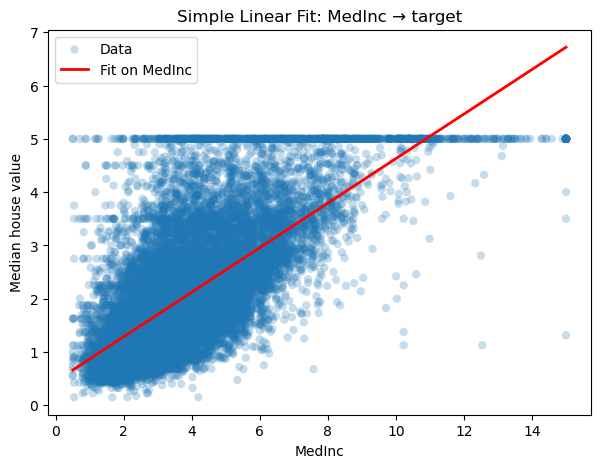

In [14]:
feature = "MedInc"
x1 = X[[feature]].values  # 2D shape for sklearn
y1 = y

# Fit a simple 1D regression for visualization (separate from your multivariate model)
lin1 = LinearRegression().fit(x1, y1)
x_grid = np.linspace(x1.min(), x1.max(), 200).reshape(-1, 1)
y_line = lin1.predict(x_grid)

plt.figure(figsize=(7,5))
plt.scatter(x1, y1, alpha=0.25, edgecolor="none", label="Data")
plt.plot(x_grid, y_line, "r", lw=2, label=f"Fit on {feature}")
plt.xlabel(feature)
plt.ylabel("Median house value")
plt.title(f"Simple Linear Fit: {feature} → target")
plt.legend()
plt.show()

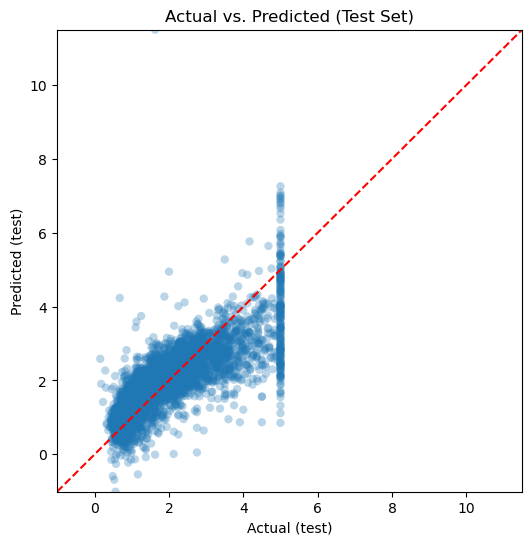

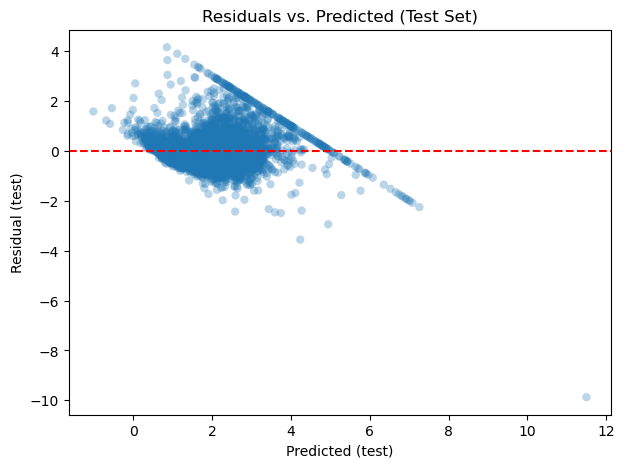

In [15]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model_tt = LinearRegression().fit(X_tr, y_tr)
y_te_pred = model_tt.predict(X_te)

plt.figure(figsize=(6,6))
plt.scatter(y_te, y_te_pred, alpha=0.3, edgecolor="none")
lims = [min(y_te.min(), y_te_pred.min()), max(y_te.max(), y_te_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual (test)")
plt.ylabel("Predicted (test)")
plt.title("Actual vs. Predicted (Test Set)")
plt.show()

res_test = y_te - y_te_pred
plt.figure(figsize=(7,5))
plt.scatter(y_te_pred, res_test, alpha=0.3, edgecolor="none")
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted (test)")
plt.ylabel("Residual (test)")
plt.title("Residuals vs. Predicted (Test Set)")
plt.show()